In [13]:
import pandas as pd
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, KFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import json
import pickle

sys.path.insert(0, "../../../utils")

from modules import *

enc = 'utf-8'

REGION = 'ExtNord'

TARGET = '_ovr5'

In [14]:
dataframe = pd.read_csv(f'../../../data/{REGION}/CM_{REGION}_Dataset_2015-2024.csv', encoding=enc)

In [15]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

In [16]:
dataframe.head()

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-10,2014,10,-0.866,...,2,17,3,12,2,17,0,0,0,0
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-10,2014,10,-0.866,...,0,0,0,0,0,0,0,0,0,0
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-10,2014,10,-0.866,...,3,83,1,0,0,1,0,0,0,0
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-10,2014,10,-0.866,...,1,8,4,3,1,8,0,0,0,0
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-10,2014,10,-0.866,...,4,41,0,3,0,3,0,0,0,0


In [17]:
dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

In [18]:
dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [19]:
dataframe.drop(columns=['Case_UND5', 'Case_PRGN', 'Case_TOTAL',
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_OVR5' : 'cases'}, inplace=True)

In [20]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377,496,0,144.44,1114,0,97,914,43
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303,489,0,149.02,1078,0,66,1078,5
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359,489,0,146.88,1124,0,89,891,63
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451,512,0,144.81,1188,0,92,1188,14
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343,481,0,145.68,1106,1,93,911,38


In [21]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [24]:
with open(f'saved/CM_{REGION}_bin_ranges{TARGET}.pkl', 'rb') as f:
    bin_ranges = pickle.load(f)

<Axes: title={'center': 'cases Distribution'}, xlabel='Bins', ylabel='Frequency'>

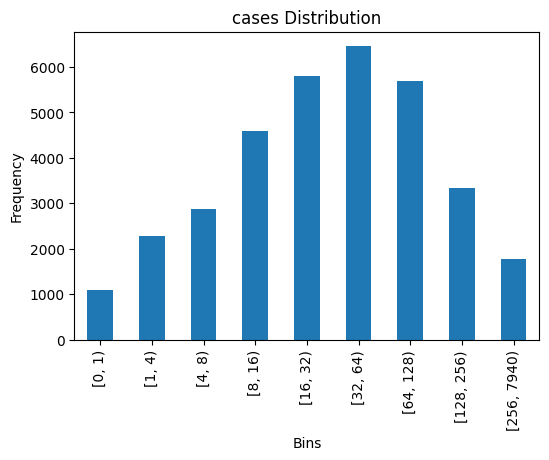

In [25]:
target_col = 'cases'

pd.cut(dataframe[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(6, 4), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

In [26]:
num_of_classes = len(bin_ranges) - 1
print(f'Number of classes: {num_of_classes}')

Number of classes: 9


In [27]:
risk_classes = list(range(0,num_of_classes))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [28]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [29]:
dataframe['case_bin'] = bins

In [30]:
dataset = dataframe.copy()

In [31]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [32]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    4    8   16   32   64  128  256 7940]


In [33]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [34]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,1377,496,0,144.44,1114,0,97,914,43,5
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,1303,489,0,149.02,1078,0,66,1078,5,2
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,1359,489,0,146.88,1124,0,89,891,63,5
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,1451,512,0,144.81,1188,0,92,1188,14,3
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,1343,481,0,145.68,1106,1,93,911,38,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33881,"(extreme nord, mayo-tsanaga, roua, madakonai)",14.023290,10.779370,2024-09,-1.000,0.0,0.557657,0.106765,-0.464755,-0.106765,...,1475,560,0,134.60,1040,1,163,959,63,5
33882,"(extreme nord, mayo-tsanaga, roua, medere)",13.986810,10.689540,2024-09,-1.000,0.0,0.563313,0.120332,-0.467706,-0.120332,...,1490,514,0,127.33,1038,1,173,946,53,5
33883,"(extreme nord, mayo-tsanaga, roua, ndimche)",13.968570,10.827287,2024-09,-1.000,0.0,0.544767,0.119364,-0.448170,-0.119364,...,1468,502,0,129.33,1044,2,175,931,29,4
33884,"(extreme nord, mayo-tsanaga, roua, roua)",13.968570,10.779370,2024-09,-1.000,0.0,0.596169,0.158170,-0.488677,-0.158170,...,1569,569,0,133.83,1146,2,180,801,20,4


In [35]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33886 entries, 0 to 33885
Data columns (total 70 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   location                 33886 non-null  object   
 1   x                        33886 non-null  float64  
 2   y                        33886 non-null  float64  
 3   dt_prediction            33886 non-null  period[M]
 4   month_sin                33886 non-null  float64  
 5   month_cos                33886 non-null  float64  
 6   ndvi                     33702 non-null  float64  
 7   ndmi                     33702 non-null  float64  
 8   ndwi                     33702 non-null  float64  
 9   ndbi                     33702 non-null  float64  
 10  ndvi_mean                33787 non-null  float64  
 11  ndmi_mean                33787 non-null  float64  
 12  ndwi_mean                33787 non-null  float64  
 13  ndbi_mean                33787 non-null  float

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
import pickle
from Model_Validation_Module import *

In [37]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [39]:
# scaler = MinMaxScaler(feature_range = (-1, 1))
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [40]:
imputer = KNNImputer(n_neighbors=3)
imputer.fit(X_train_scaled)
X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

In [41]:
X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

In [42]:
X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

In [43]:
with open(f'saved/CM_{REGION}_gridcv_best_params{TARGET}.json', 'r') as f:
    model_params = json.load(f)

In [44]:
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 0)
rfe = RFECV(xgb.XGBRegressor(**model_params), step=1, cv=cv, scoring = 'neg_mean_squared_error',  n_jobs=-1)
fitted_rfe = rfe.fit(X_train_imputed, y_train)

In [45]:
fitted_rfe

RFECV(cv=StratifiedKFold(n_splits=10, random_state=0, shuffle=True),
      estimator=XGBRegressor(base_score=None, booster=None, callbacks=None,
                             colsample_bylevel=None, colsample_bynode=None,
                             colsample_bytree=None, device=None,
                             early_stopping_rounds=None,
                             enable_categorical=False, eval_metric=None,
                             feature_types=None, gamma=0, grow_policy=None,
                             importance_type=None, interaction_constraints=None,
                             learning_rate=0.1, max_bin=None,
                             max_cat_threshold=None, max_cat_to_onehot=None,
                             max_delta_step=None, max_depth=7, max_leaves=None,
                             min_child_weight=3, missing=nan,
                             monotone_constraints=None, multi_strategy=None,
                             n_estimators=300, n_jobs=None,
                             num_parallel_tree=None, random_state=None, ...),
      n_jobs=-1, scoring='neg_mean_squared_error')

In [ ]:
with open(f'saved/CM_{REGION}_rfecv_model{TARGET}.pkl', 'wb') as f:
    pickle.dump(fitted_rfe, f)

In [46]:
X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

In [47]:
features_chosen = X_train_rfe.columns.to_list()

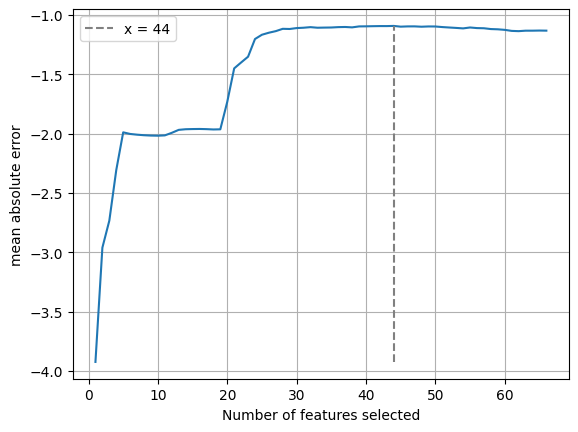

In [48]:
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("mean absolute error")
plt.plot(range(1,len(fitted_rfe.cv_results_['mean_test_score']) + 1), fitted_rfe.cv_results_['mean_test_score'])
plt.vlines(x = np.argmax(fitted_rfe.cv_results_['mean_test_score'])+1,
                   ls='--', ymin = np.min(fitted_rfe.cv_results_['mean_test_score']),
                   ymax = np.max(fitted_rfe.cv_results_['mean_test_score']), colors = 'grey',
                   label = 'x = '+str(np.argmax(fitted_rfe.cv_results_['mean_test_score'])+1))
plt.grid()
plt.legend()
plt.show()

In [49]:
model = xgb.XGBRegressor(**model_params)

In [50]:
fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

In [51]:
y_train_proba = fitted_model.predict(X_train_rfe)
y_test_proba = fitted_model.predict(X_test_rfe)

In [52]:
y_train_pred = np.clip(np.round(y_train_proba), 0, num_of_classes-1).astype(int)
y_test_pred = np.clip(np.round(y_test_proba), 0, num_of_classes-1).astype(int)


In [53]:
results_train = pd.DataFrame({'actual': y_train,'prediction': y_train_pred})
results_test = pd.DataFrame({'actual': y_test,'prediction': y_test_pred})

results_test['dt_prediction'] = dataset.loc[results_test.index, 'dt_prediction']
results_test['dt_temp'] = results_test['dt_prediction']+3

results_train.reset_index(drop=True, inplace=True)
results_test.reset_index(drop=True, inplace=True)

In [54]:
metrics(results_train, results_test, threshold=1)

MAE on train set: 0.4298
MSE on train set: 0.5072
min prediction: 0
max prediction: 8

MAE on test set: 0.7403
MSE on test set: 1.1660
Error <= 1: 86.65 %
min prediction: 0
max prediction: 8


In [55]:
len(features_chosen)

44

In [56]:
features_chosen

['x',
 'y',
 'month_cos',
 'ndvi_std',
 'rainfall',
 'rainfall_acc_prev_month',
 'distance_to_coast',
 'distance_to_river',
 'slope_mean_1km',
 'aspect_mean_200m',
 'elevation_mean_1km',
 'hillshade_mean_1km',
 'flow_accu_200m',
 'distance_to_coast_std',
 'distance_to_river_std',
 'slope_mean_1km_std',
 'aspect_mean_200m_std',
 'elevation_mean_1km_std',
 'hillshade_mean_1km_std',
 'flow_accu_200m_std',
 'lc_prop1',
 'lc_prop2',
 'lc_type1',
 'lc_type2',
 'lc_type3',
 'lc_type4',
 'bio1',
 'bio2',
 'bio3',
 'bio4',
 'bio5',
 'bio6',
 'bio7',
 'bio8',
 'bio9',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19']

In [57]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    group_by='class',
    metric='mae',
    title='MAE per Risk Class'
)

In [58]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    date_col='dt_prediction',
    group_by='month',
    metric='mae',
    title='Monthly MAE'
)

In [59]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    date_col='dt_temp',
    group_by='year',
    metric='mae',
    title='Yearly MAE'
)

In [60]:
plot_hist_plotly(results_test['actual'].cat.codes, results_test['prediction'])